<a href="https://colab.research.google.com/github/Akshayus29/Assignments/blob/main/intermediate_assessment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier #KNN
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report,roc_auc_score
from sklearn.naive_bayes import GaussianNB #NB
from sklearn.tree import DecisionTreeClassifier #DT
from sklearn.svm import SVC #SVM
from sklearn.model_selection import GridSearchCV #model fine tuning
from sklearn.ensemble import RandomForestClassifier  # Model Feature Selection
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram,linkage
from sklearn.cluster import AgglomerativeClustering

### Load Train Data

In [2]:
file_path = '/content/drive/MyDrive/DSA folder/Data/iintermediate_assessment/train_LZdllcl.csv'
df_train = pd.read_csv(file_path)
df_train.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,1,0,49,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,0,50,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,0,50,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,0,73,0


In [3]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  object 
 2   region                54808 non-null  object 
 3   education             52399 non-null  object 
 4   gender                54808 non-null  object 
 5   recruitment_channel   54808 non-null  object 
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  50684 non-null  float64
 9   length_of_service     54808 non-null  int64  
 10  KPIs_met >80%         54808 non-null  int64  
 11  awards_won?           54808 non-null  int64  
 12  avg_training_score    54808 non-null  int64  
 13  is_promoted           54808 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.9+ MB


### **Handling missing values**

In [4]:
df_train.duplicated().sum()

np.int64(0)

In [5]:
df_train.isnull().sum()

,0
employee_id,0
department,0
region,0
education,2409
gender,0
recruitment_channel,0
no_of_trainings,0
age,0
previous_year_rating,4124
length_of_service,0


## Calculate Skewness




In [6]:
numerical_cols = ['no_of_trainings', 'age', 'previous_year_rating', 'length_of_service', 'KPIs_met >80%', 'awards_won?', 'avg_training_score']
skewness_values = df_train[numerical_cols].skew()
print("Skewness for numerical columns:\n", skewness_values)

Skewness for numerical columns:
 no_of_trainings         3.445434
age                     1.007432
previous_year_rating   -0.310638
length_of_service       1.738061
KPIs_met >80%           0.619909
awards_won?             6.338914
avg_training_score      0.451908
dtype: float64


### Visualize Distributions with Histograms

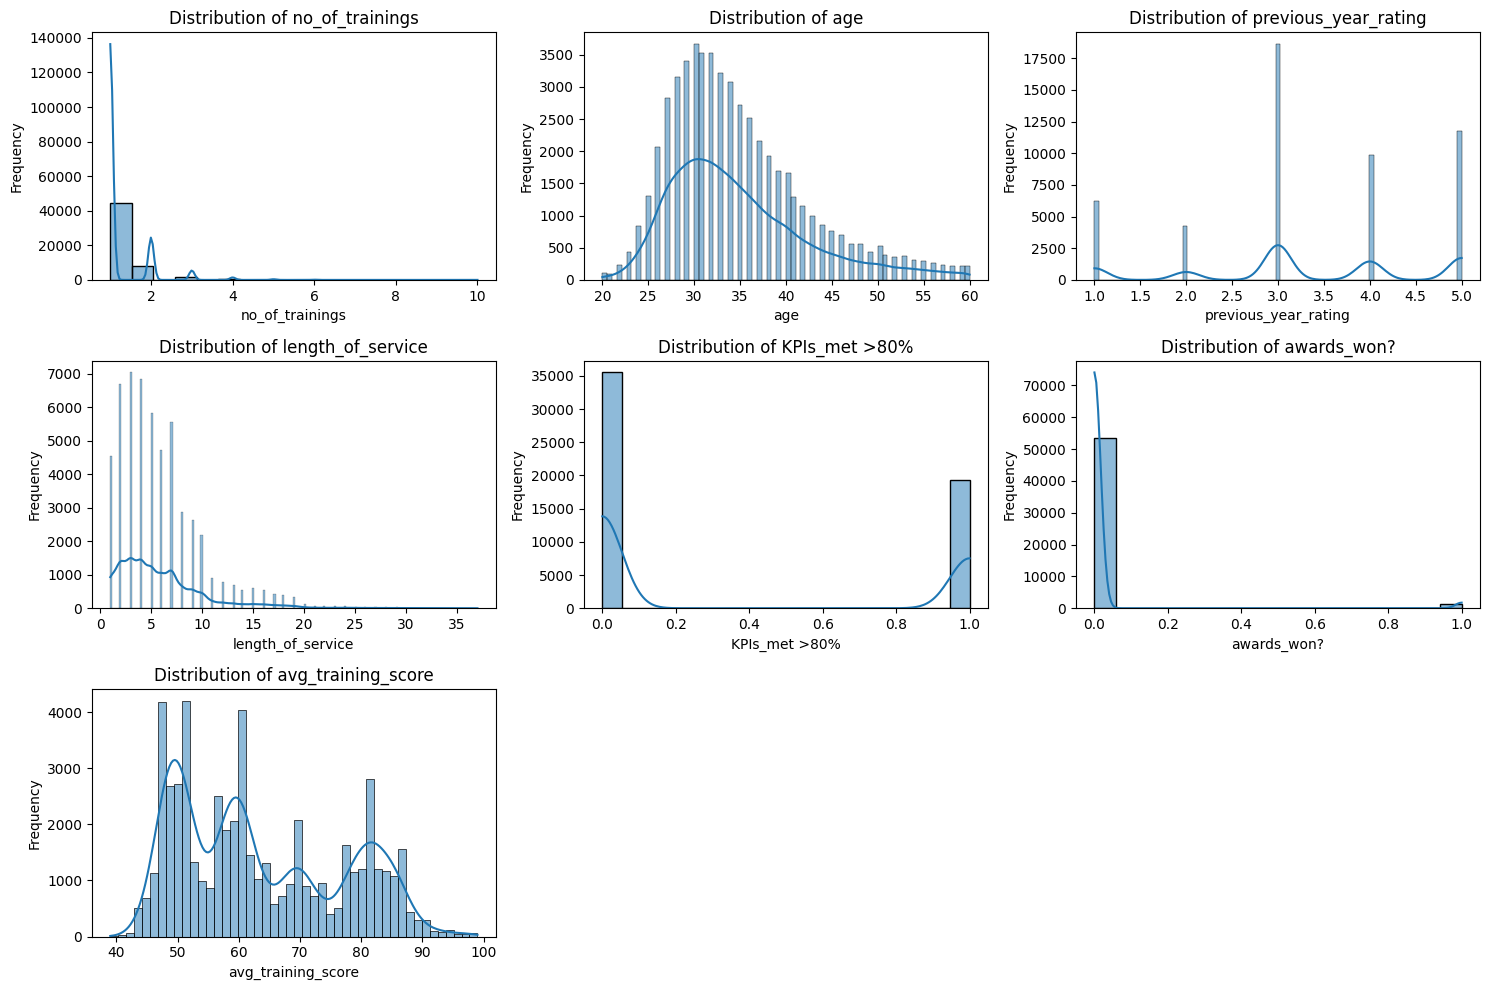

In [7]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid based on number of numerical columns
    sns.histplot(df_train[col].dropna(), kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


In [8]:
df_train['previous_year_rating']=df_train['previous_year_rating'].fillna(df_train['previous_year_rating'].mean())

In [9]:
df_train['education']=df_train['education'].fillna(df_train['education'].mode()[0])

In [10]:
df_train.isnull().sum()

,0
employee_id,0
department,0
region,0
education,0
gender,0
recruitment_channel,0
no_of_trainings,0
age,0
previous_year_rating,0
length_of_service,0


### **Handling outliers**

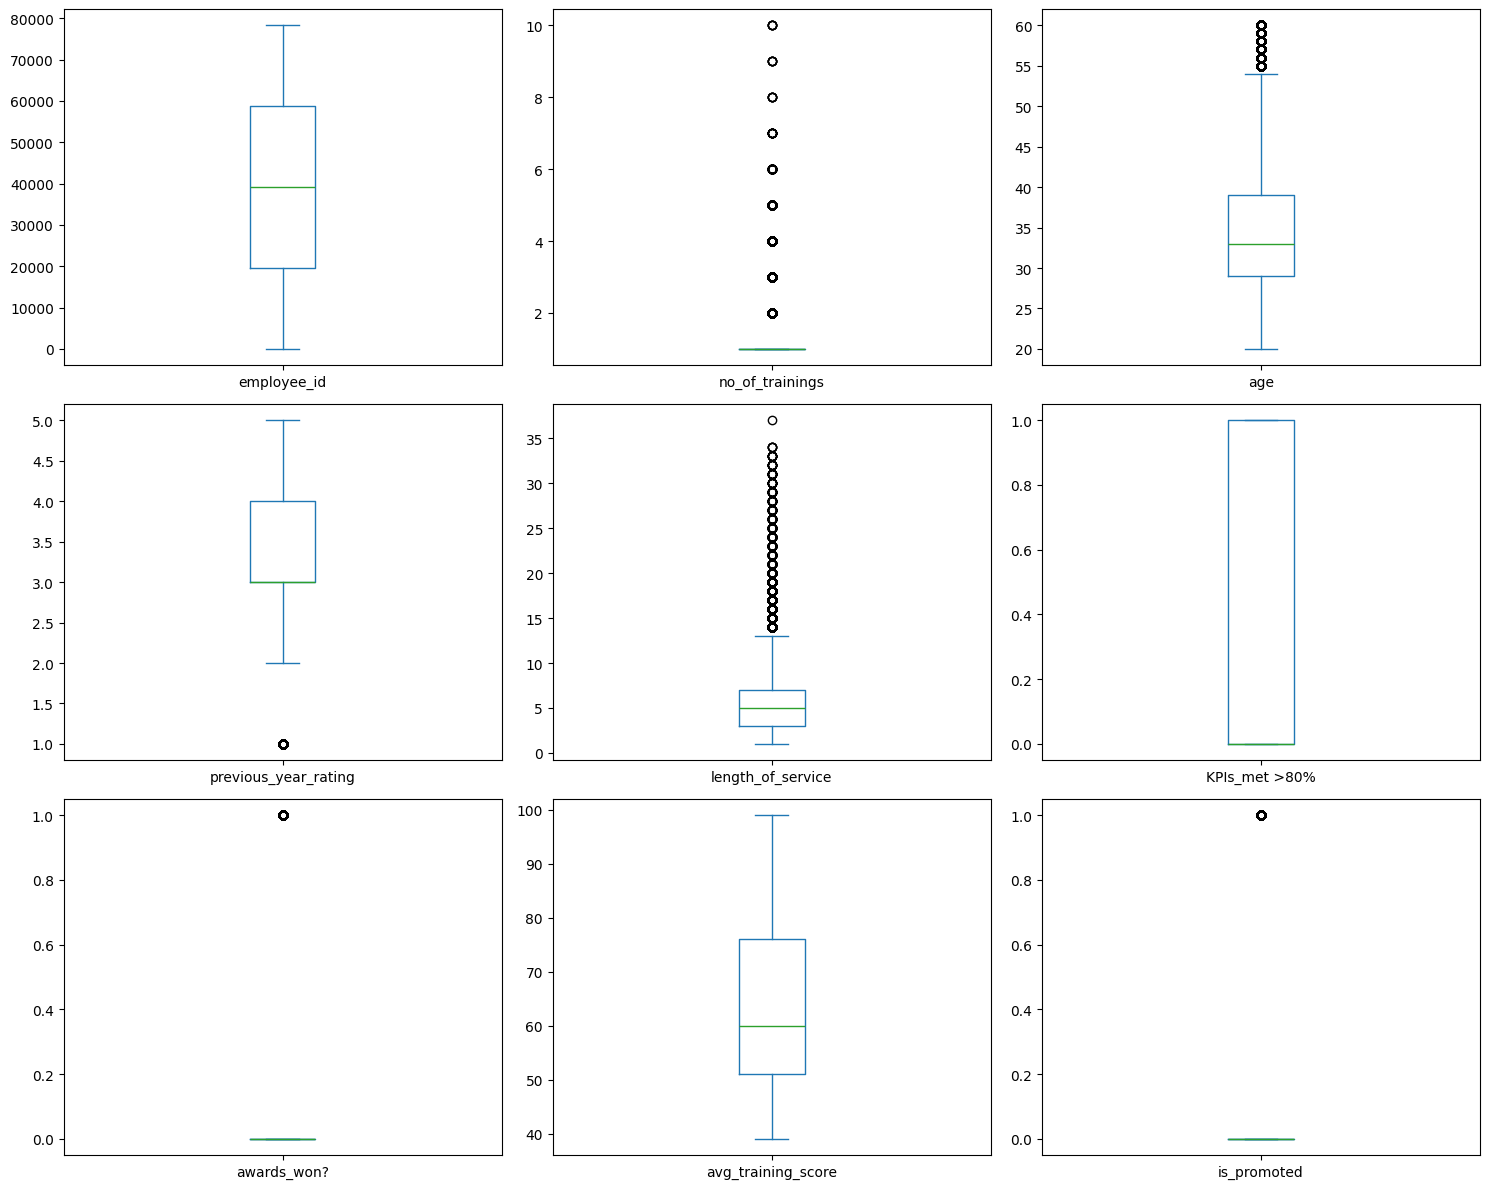

In [11]:

# 1. Select only numerical columns
num_cols = df_train.select_dtypes(include=['int64', 'float64']).columns

# 2. Use a 3x3 layout (fits 9 plots)
# 'vert=False' makes them horizontal like you wanted
df_train[num_cols].plot(
    kind='box',
    subplots=True,
    layout=(3, 3),
    figsize=(15, 12),

)

plt.tight_layout()
plt.show()

### **Encoding**

In [12]:
region_freq_map = df_train['region'].value_counts(normalize=True).to_dict()
df_train['region'] = df_train['region'].map(region_freq_map)

In [13]:
df_train['region'].value_counts()

,count
region,
0.225204,12343
0.117282,6428
0.088363,4843
0.051233,2808
0.048314,2648
0.041235,2260
0.035305,1935
0.031072,1703
0.030269,1659


label encoding

In [14]:
label_cols = ['department', 'education', 'gender', 'recruitment_channel']

le = LabelEncoder()
for col in label_cols:
    df_train[col] = le.fit_transform(df_train[col])
display(df_train.head())

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
0,65438,7,0.088363,2,0,2,1,35,5.0,8,1,0,49,0
1,65141,4,0.117282,0,1,0,1,30,5.0,4,0,0,60,0
2,7513,7,0.015947,0,1,2,1,34,3.0,7,0,0,50,0
3,2542,7,0.021438,0,1,0,2,39,1.0,10,0,0,50,0
4,48945,8,0.041235,0,1,0,1,45,3.0,2,0,0,73,0


### Train-Test Split

In [15]:
df_train1= df_train.drop(columns=['employee_id'])

In [16]:
X = df_train1.drop('is_promoted', axis=1)
y = df_train1['is_promoted']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

# random_state=55)

In [17]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(43846, 12)
(10962, 12)
(43846,)
(10962,)


### scaling

min max scaling

In [18]:
ss = MinMaxScaler()
X_train=ss.fit_transform(X_train)
X_test=ss.transform(X_test)

#ML Modeling Using Classification Methods

Logistic Regression model

In [19]:
lr=LogisticRegression()
lr.fit(X_train,y_train)

LogisticRegression()

In [20]:
y_pred_lr=lr.predict(X_test)

In [21]:
print(f'accuracy_score= {accuracy_score(y_test,y_pred_lr)}')
print(f'precision= {precision_score(y_test,y_pred_lr)}')
print(f'f1= {f1_score(y_test,y_pred_lr)}')
print(f'recall= {recall_score(y_test,y_pred_lr)}')
print(f'conf_matrix= {confusion_matrix(y_test,y_pred_lr)}')
print(f'classification_report= {classification_report(y_test,y_pred_lr)}')

accuracy_score= 0.9215471629264733
precision= 0.6559139784946236
f1= 0.12423625254582485
recall= 0.0686164229471316
conf_matrix= [[10041    32]
 [  828    61]]
classification_report=               precision    recall  f1-score   support

           0       0.92      1.00      0.96     10073
           1       0.66      0.07      0.12       889

    accuracy                           0.92     10962
   macro avg       0.79      0.53      0.54     10962
weighted avg       0.90      0.92      0.89     10962



KNN model

euclidian


In [22]:
#we need to figure out the optimum value for k.
#to do that, we will check which value of k is giving highest accuracy.

accuracy_list = []
neighbors_range = np.arange(1,30)

for k in neighbors_range:
  classifier = KNeighborsClassifier(n_neighbors=k , metric='minkowski',p=2)  # initialising classifier for iteration using Euclidian p=2
  #Training the ML model
  classifier.fit(X_train, y_train)
  y_pred_eu=classifier.predict(X_test)  #predict using trained ML model
  acc = accuracy_score(y_test,y_pred_eu)  # evaluate the ML model
  accuracy_list.append(acc) #appending acc list with accuracy achieved for each value of k

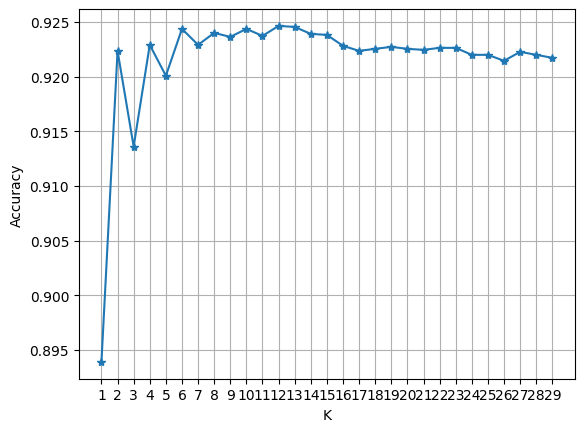

In [23]:
plt.plot(neighbors_range, accuracy_list,'*-')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.xticks(neighbors_range)
plt.grid()

In [24]:
#taking value of k = 6

classifier_knn = KNeighborsClassifier(n_neighbors=6, metric='euclidean')
classifier_knn.fit(X_train,y_train)
y_pred_knn_eu = classifier_knn.predict(X_test)
acc_knn=accuracy_score(y_test,y_pred_knn_eu)
prec_knn=precision_score(y_test,y_pred_knn_eu)
rec_knn=recall_score(y_test,y_pred_knn_eu)
f1_knn=f1_score(y_test,y_pred_knn_eu)


In [25]:
print('Accuracy:',acc_knn)
print('Precision:',prec_knn)
print('Recall:',rec_knn)
print('F1 Score:',f1_knn)
confusion_matrix(y_test,y_pred_knn_eu)

Accuracy: 0.9243751140302865
Precision: 0.7
Recall: 0.11811023622047244
F1 Score: 0.20211742059672763


array([[10028,    45],
       [  784,   105]])

Manhattan

In [26]:
accuracy_list1 = []
neighbors_range1 = np.arange(1,30)

for k in neighbors_range:
  classifier1 = KNeighborsClassifier(n_neighbors=k , metric='minkowski',p=1)  # initialising classifier for iteration using manhattan p=1
  #Training the ML model
  classifier1.fit(X_train, y_train)
  y_pred_mn=classifier1.predict(X_test)  #predict using trained ML model
  acc1 = accuracy_score(y_test,y_pred_mn)  # evaluate the ML model
  accuracy_list1.append(acc1) #appending acc list with accuracy achieved for each value of k

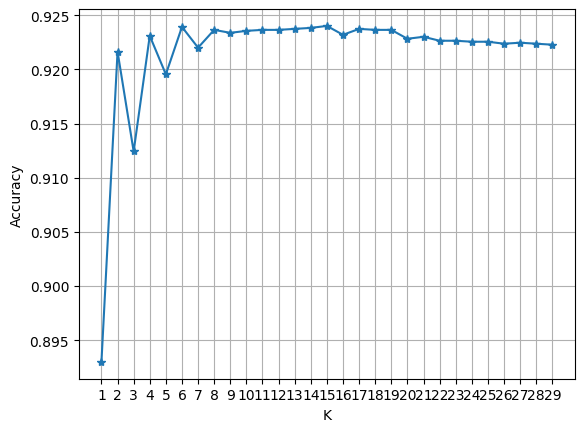

In [27]:
plt.plot(neighbors_range1, accuracy_list1,'*-')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.xticks(neighbors_range1)
plt.grid()

In [28]:
#using K=6
classifier1_knn = KNeighborsClassifier(n_neighbors=6, metric='manhattan')
classifier1_knn.fit(X_train,y_train)
y_pred_knn_mn = classifier1_knn.predict(X_test)
acc_knn1=accuracy_score(y_test,y_pred_knn_mn)
prec_knn1=precision_score(y_test,y_pred_knn_mn)
rec_knn1=recall_score(y_test,y_pred_knn_mn)
f1_knn1=f1_score(y_test,y_pred_knn_mn)

In [29]:
print('Accuracy:',acc_knn1)
print('Precision:',prec_knn1)
print('Recall:',rec_knn1)
print('F1 Score:',f1_knn1)
confusion_matrix(y_test,y_pred_knn_mn)

Accuracy: 0.9233716475095786
Precision: 0.6644295302013423
Recall: 0.11136107986501688
F1 Score: 0.1907514450867052


array([[10023,    50],
       [  790,    99]])

Naive Baye's

In [30]:
#initializing the model
nb=GaussianNB()
#training the model
nb.fit(X_train,y_train)
#predict using trained ML model
y_pred_nb=nb.predict(X_test)
#evaluate the model
acc_nb=accuracy_score(y_test,y_pred_nb)
prec_nb=precision_score(y_test,y_pred_nb)
rec_nb=recall_score(y_test,y_pred_nb)
f1_nb=f1_score(y_test,y_pred_nb)

In [31]:
print('Accuracy:',acc_nb)
print('Precision:',prec_nb)
print('Recall:',rec_nb)
print('F1 Score:',f1_nb)
confusion_matrix(y_test,y_pred_nb)

Accuracy: 0.9168947272395548
Precision: 0.4573643410852713
Recall: 0.1327334083239595
F1 Score: 0.2057541412380122


array([[9933,  140],
       [ 771,  118]])

Decision Tree

In [32]:
#initializing the model
dt=DecisionTreeClassifier()
#training the model
dt.fit(X_train,y_train)
#predict using trained ML model
y_pred_dt=dt.predict(X_test)
#evaluate the model
acc_dt=accuracy_score(y_test,y_pred_dt)
prec_dt= precision_score(y_test,y_pred_dt)
rec_dt=recall_score(y_test,y_pred_dt)
f1_dt=f1_score(y_test,y_pred_dt)

In [33]:
print('Accuracy:',acc_dt)
print('Precision:',prec_dt)
print('Recall:',rec_dt)
print('F1 Score:',f1_dt)
confusion_matrix(y_test,y_pred_dt)

Accuracy: 0.8963692756796205
Precision: 0.3809064609450338
Recall: 0.44431946006749157
F1 Score: 0.4101765316718588


array([[9431,  642],
       [ 494,  395]])

SVM (SVC)

In [34]:
svm_clf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=55)  ##initializing the model
svm_clf.fit(X_train, y_train)   ##training the model
y_pred_sv = svm_clf.predict(X_test)  ##training the model

In [35]:
#evaluating the model
acc_sv=accuracy_score(y_test,y_pred_sv)
prec_sv= precision_score(y_test,y_pred_sv)
rec_sv=recall_score(y_test,y_pred_sv)
f1_sv=f1_score(y_test,y_pred_sv)


print('Accuracy:',acc_sv)
print('Precision:',prec_sv)
print('Recall:',rec_sv)
print('F1 Score:',f1_sv)
confusion_matrix(y_test,y_pred_sv)

Accuracy: 0.9240102171136654
Precision: 0.8111111111111111
Recall: 0.08211473565804274
F1 Score: 0.1491317671092952


array([[10056,    17],
       [  816,    73]])

### KNN Model Fine Tuning using Grid Search CV

In [36]:
param_grid_knn = {
    'n_neighbors': list(range(1, 31)),
    'metric': ['euclidean', 'manhattan']
}

print(param_grid_knn)

{'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30], 'metric': ['euclidean', 'manhattan']}


In [37]:
knn = KNeighborsClassifier()
grid_search_knn = GridSearchCV(estimator=knn, param_grid=param_grid_knn, cv=5, scoring='accuracy', n_jobs=-1)

print("GridSearchCV for KNN initialized.")

GridSearchCV for KNN initialized.


In [38]:
grid_search_knn.fit(X_train, y_train)

print("GridSearchCV fitting complete.")

GridSearchCV fitting complete.


In [39]:
print("Best parameters for KNN:", grid_search_knn.best_params_)
print("Best score for KNN:", grid_search_knn.best_score_)

Best parameters for KNN: {'metric': 'euclidean', 'n_neighbors': 6}
Best score for KNN: 0.9191488935639738


In [40]:
best_knn = grid_search_knn.best_estimator_
y_pred_best_knn = best_knn.predict(X_test)

print("KNN (Fine-Tuned) Performance on Test Set:")
print(f'Accuracy: {accuracy_score(y_test, y_pred_best_knn)}')
print(f'Precision: {precision_score(y_test, y_pred_best_knn)}')
print(f'Recall: {recall_score(y_test, y_pred_best_knn)}')
print(f'F1 Score: {f1_score(y_test, y_pred_best_knn)}')
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred_best_knn))

KNN (Fine-Tuned) Performance on Test Set:
Accuracy: 0.9243751140302865
Precision: 0.7
Recall: 0.11811023622047244
F1 Score: 0.20211742059672763
Confusion Matrix:
 [[10028    45]
 [  784   105]]


# Load Test Data

In [41]:
filepath='/content/drive/MyDrive/DSA folder/Data/iintermediate_assessment/test_2umaH9m.csv'
df_test=pd.read_csv(filepath)
df_test.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score
0,8724,Technology,region_26,Bachelor's,m,sourcing,1,24,NaN,1,1,0,77
1,74430,HR,region_4,Bachelor's,f,other,1,31,3.0,5,0,0,51
2,72255,Sales & Marketing,region_13,Bachelor's,m,other,1,31,1.0,4,0,0,47
3,38562,Procurement,region_2,Bachelor's,f,other,3,31,2.0,9,0,0,65
4,64486,Finance,region_29,Bachelor's,m,sourcing,1,30,4.0,7,0,0,61


In [42]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23490 entries, 0 to 23489
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           23490 non-null  int64  
 1   department            23490 non-null  object 
 2   region                23490 non-null  object 
 3   education             22456 non-null  object 
 4   gender                23490 non-null  object 
 5   recruitment_channel   23490 non-null  object 
 6   no_of_trainings       23490 non-null  int64  
 7   age                   23490 non-null  int64  
 8   previous_year_rating  21678 non-null  float64
 9   length_of_service     23490 non-null  int64  
 10  KPIs_met >80%         23490 non-null  int64  
 11  awards_won?           23490 non-null  int64  
 12  avg_training_score    23490 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 2.3+ MB


In [43]:
df_test['education']= df_train['education'].fillna(df_train['education'].mode()[0])

In [44]:
df_test['previous_year_rating']=df_test['previous_year_rating'].fillna(df_test['previous_year_rating'].mean())

In [45]:
df_test.isnull().sum().sort_values(ascending=False)

,0
employee_id,0
department,0
region,0
education,0
gender,0
recruitment_channel,0
no_of_trainings,0
age,0
previous_year_rating,0
length_of_service,0


### Encoding

frequency encoding

In [46]:
region_freq_map = df_test['region'].value_counts(normalize=True).to_dict()
df_test['region'] = df_test['region'].map(region_freq_map)

In [47]:
df_test['region'].value_counts()

,count
region,
0.225585,5299
0.116603,2739
0.084376,1982
0.049681,1167
0.048106,1130
0.043040,1011
0.035930,844
0.032993,775
0.030226,710


label encoding

In [48]:
for col in label_cols:
    df_test[col] = le.fit_transform(df_test[col])

In [49]:
df_test.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score
0,8724,8,0.043040,2,1,2,1,24,3.339146,1,1,0,77
1,74430,2,0.032993,0,0,0,1,31,3.000000,5,0,0,51
2,72255,7,0.049681,0,1,0,1,31,1.000000,4,0,0,47
3,38562,5,0.225585,0,0,0,3,31,2.000000,9,0,0,65
4,64486,1,0.017625,0,1,2,1,30,4.000000,7,0,0,61


### Scaling

minmax scaling

In [50]:
df_test = df_test.drop(columns=['employee_id'])

In [51]:
df_test=ss.transform(df_test)

### ML Modeling using fine tuned Logistic Regression

In [66]:
y_pred_test = best_knn.predict(df_test)

### submission file creation

In [60]:
file_path = '/content/drive/MyDrive/DSA folder/Data/iintermediate_assessment/sample_submission_M0L0uXE.csv'

df_sample = pd.read_csv(file_path)
df_sample


,employee_id,is_promoted
0,8724,0
1,74430,0
2,72255,0
3,38562,0
4,64486,0
...,...,...
23485,53478,0
23486,25600,0
23487,45409,0
23488,1186,0


In [61]:
df_sample['is_promoted'] = y_pred_test


In [65]:
df_sample.to_csv('final_submission.csv', index=False)
